# Метод опорных векторов

## Описание метода SVM

Метод опорных векторов (Support Vector Machines или просто SVM) — мощный и универсальный набор алгоритмов для работы с данными любой формы, применяемый не только для задач классификации и регрессии, но и также для выявления аномалий.

## Варианты разделения опорными векторами: задача классификации SVC

1) Классификация с жёстким зазором (hard margin), когда все обучающие образцы должны быть правильно классифицированы и находиться за пределами полосы разделения. Такой подход работает только в случае хорошей линейной разделимости данных и является довольно чувствительным к выбросам.

2) Классификация с мягким зазором (soft margin), когда вводится допущение, что некоторые обучающие образцы могут нарушать условие правильной классификации или попадать в полосу разделения, но при этом вводится штраф за такие нарушения, пропорциональный параметру $C$ (чем ниже данное значение, тем шире полоса и больше нарушений попадает в зазор). При таком подходе увеличивается обобщающая способность модели, что позволяет снизить риск переобучения.

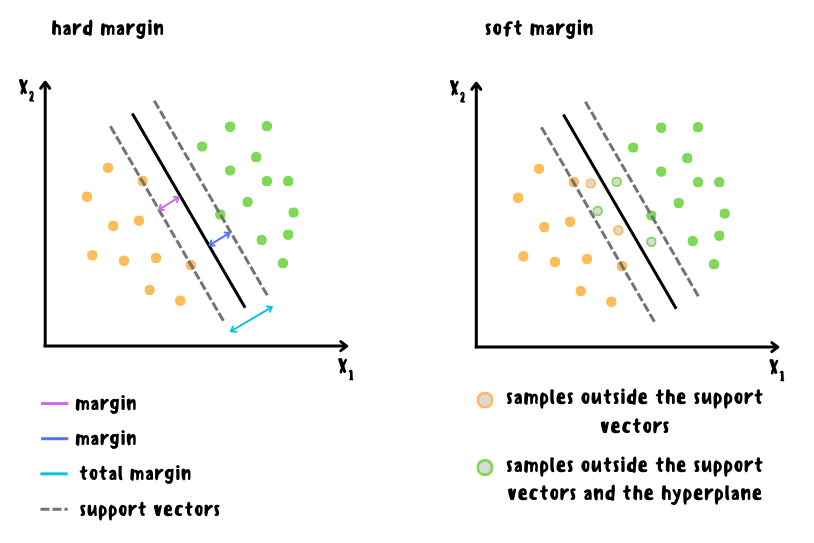

В результате производится минимализация следующей функции потерь:

$$
min \rightarrow C \sum \limits_{i=1}^{n} max(0, 1 - y_i (w^TX + b))
$$

Рассмотрим данное уравнение:

## 1. Выражение $y_i (w^TX + b)$

Это проверка «правильности» классификации для одной точки $i$.

$y_i$ — истинный класс точки (1 или -1).
$(w^TX + b)$ — предсказание модели (насколько далеко точка ушла от разделяющей линии).

Если знаки совпадают (точка с классом +1 лежит в зоне +1), результат будет положительным. Это хорошо.

Если знаки разные (ошибка), результат будет отрицательным. Это плохо.

## 2. Функция $\max(0,1)$

Это и есть Hinge Loss (петлеобразная потеря). Она наказывает модель за ошибки:

Если результат $\geq 1$: Точка классифицирована верно и находится достаточно далеко от границы (за пределами «безопасного зазора»). Ошибка = 0.

Если результат $<1$: Точка либо на правильной стороне, но слишком близко к границе (внутри зазора), либо вообще на чужой стороне. В этом случае 1 даст положительное число — это штраф, который модель должна уменьшить.

## 3. Сумма $\sum$ и коэффициент $C$

- Сумма: Мы складываем штрафы за все точки данных.

- Параметр $C$: Это «регулятор строгости».
    - Большое $C$: Модель очень боится ошибиться на обучающих данных. Она будет строить узкий зазор, лишь бы не пропустить ни одной точки (риск переобучения).
    - Маленькое $C$: Модель допускает ошибки ради того, чтобы разделяющая полоса (зазор) была шире и стабильнее.

При реализации scikit-learn дополнительно к данным весам добавляется регуляризация, которая позволяет минимизировать влияние слишком большого количества коэффициентов в модели.

Как видно из данного разбора, у нас получается бинарный классификатор. Для того, чтобы была возможность построить разделение на более чем 2 класса существует 2 стратегии:

1) **Один против всех (One-vs-Rest / One-vs-All)**
Это самый популярный метод. Для $N$ классов строится $N$ отдельных моделей SVM.
- **Как это работает:** Первая модель учится отличать «кошек» от «всех остальных» (собак и лошадей вместе). Вторая — «собак» от «всех остальных» и т.д.
- **Результат:** При классификации нового объекта побеждает тот класс, чья модель выдала наибольшее значение (самую высокую уверенность).

2. **Каждый против каждого (One-vs-One)**
Строится отдельный SVM для каждой пары классов.
- **Как это работает:** Если классов 3, будет 3 модели: (Кошка vs Собака), (Кошка vs Лошадь), (Собака vs Лошадь).
- **Результат:** Каждая модель «голосует» за свой класс. Объект относят к тому классу, который набрал больше всего голосов.

## Регрессионный вариант SVM (SVR)

В случае линейной регрессии SVM пытается минимизировать расстояние между зазором и образцами, что лежат за его пределами, а добавление дополнительных обучающих образцов внутрь зазора не влияет на итоговый прогноз. Проще говоря, принцип такой же как и в обычной линейной регрессии, но вместо линии используется зазор, ширина которого контролируется параметром epsilon, а минимизируемая функция потерь называется **epsilon-insensitive**:

$$ 
\min \rightarrow C \sum\limits_{i=1}^{n} \max(0, |y_i - (w^T \phi(x_i) + b)| - \varepsilon)
$$

Следовательно, логика меняется: если в классификации мы пытались **"растолкать"** классы подальше от линии, то в регрессии мы пытаемся **"собрать"** все точки внутри определенного коридора вокруг линии.

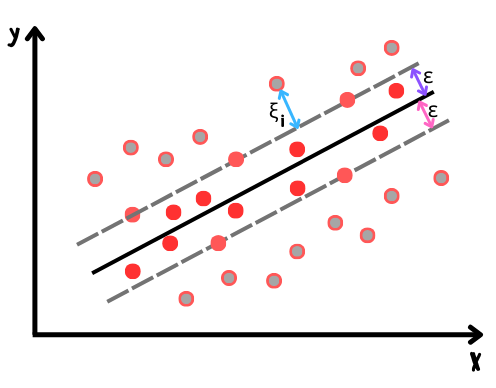

## Описание алгоритма

Вместо одной линии регрессия строит «трубку» шириной $2\varepsilon$.

- $\varepsilon$ (эпсилон): Это допустимая ошибка. Если точка данных попадает внутрь трубки (то есть предсказание отличается от реальности меньше чем на $\varepsilon$), мы считаем это идеальным результатом и штраф равен 0.

### Разбор формулы

$$|y_i - (w^T \phi(x_i) + b)| - \varepsilon$$

- $(w^T \phi(x_i) + b$ - предсказание модели для точки $x_i$
- $|y_i - предсказание|$ - Абсолютное расстояние (ошибка) от реального значения $y_i$ до нашей линии.
- $\varepsilon$ - минус допустимая погрешность

#### Логика $max(0, ...)$:
- Если ошибка меньше $\varepsilon$, результат в скобках отрицательный, и $max(0, отрицательное)$ дает 0. Модель не штрафуется.
- Если ошибка больше $\varepsilon$, точка лежит вне «трубки». Модель получает штраф, равный величине этого выхода за пределы.

#### Параметр C

Как и в классификации, это баланс:
- Большое C: Модель очень жестко штрафует за любой выход за пределы трубки. Линия будет пытаться максимально подстроиться под каждую точку (риск переобучения).
- Маленькое C: Модели «все равно» на небольшие выходы за границы, она стремится к более плавной и простой линии.

В отличие от обычной регрессии (MSE), где штрафуется любая, даже мизерная ошибка, SVR игнорирует ошибки меньше $\varepsilon$, что делает её очень устойчивой к шуму и выбросам.

## Ядерный трюк (Kernel Trick)

Это приём работы с данными в исходном пространстве, при котором скалярное произведение трансформированных векторов n-й степени заменяется на их произведение в степени n, что даёт аналогичный результат. Проще говоря, такой подход позволяет получить такие же результаты, как и в случае с добавлением большого количества полиномиальных признаков без их фактического добавления:

$$\phi(a)^T \cdot \phi(b) = (a^T \cdot b)^n$$

Ниже представлен пример ядерного трюка для полиномиальноrо отображения второй степени.

$$\phi(a)^T \cdot \phi(b) =
\left( \begin{array}{c} a_1^2 \\ \sqrt{2} a_1 a_2  \\ a_2^2 \end{array} \right)^T \cdot
\left( \begin{array}{c} b_1^2 \\ \sqrt{2} b_1 b_2  \\ b_2^2 \end{array} \right) =
a_1^2 b_1^2 + 2a_1 b_1 a_2 b_2 + a_2^2 b_2^2 = \\
= (a_1 b_1 + a_2 b_2)^2 =
\left( \begin{array}{c} \left( \begin{array}{c} a_1 \\ a_2 \end{array} \right)^T \cdot
\left( \begin{array}{c} b_1 \\ b_2 \end{array} \right) \end{array} \right)^2 = (a^T \cdot b)^2$$

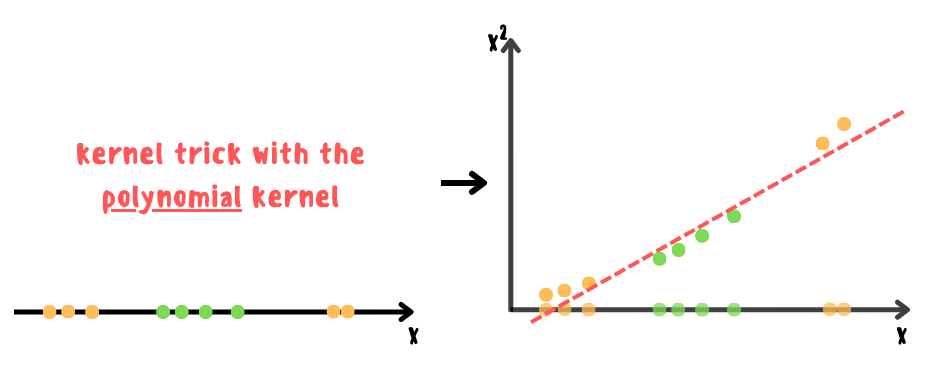

### Возможные ядра в scikit-learn

- линейное — просто вычисляет скалярное произведение векторов в исходном пространстве, что эквивалентно обычному линейному классификатору:
$$a^T \cdot b$$

- полиномиальное — способно улавливать более сложные зависимости между данными, создавая оптимальную разделяющую гиперплоскость в новом пространстве, однако требуется тщательный подбор параметров:

$$(\gamma a^T \cdot b + r)^d$$

- гауссовское RBF (радиально-базисная функция) — хорошо подходит для случаев, когда отношение в данных имеет сложную нелинейную форму и менее подвержено переобучению, поскольку учитывает не только значения признаков, но и их распределение:
$$exp(-\gamma||a - b||^2)$$

- сигмоидальное — применяет гиперболический тангенс к линейной комбинации векторов, имитируя использование двухслойной нейронной сети с сигмоидальной функцией активации, что также позволяет хорошо работать со сложными нелинейными случаями, однако это может привести к переобучению в случае появления шума и выбросов:

$$tanh(\gamma a^t \cdot b + r)$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.utils import check_random_state, check_array
from sklearn.svm import LinearSVC, LinearSVR, SVC, SVR, _libsvm
from sklearn.datasets import load_iris

In [3]:
class LinearSVM:
    def __init__(self, regression=False, C=1.0, eps=0, learning_rate=0.001, max_iter=10000,
                 random_state=0):
        self.regression = regression
        self.C = C
        self.eps = eps
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        if self.regression:
            self.bias, self.weights = self._find_weights(X, y)
        else:
            classes = np.unique(y)
            n_classes = len(classes)
            _, n_features = X.shape

            self.bias = np.zeros(n_classes)
            self.weights = np.zeros((n_classes, n_features))
            np.random.seed(self.random_state)

            for i, cls in enumerate(classes):
                y_binary = np.where(y == cls, 1, -1)
                self.bias[i], self.weights[i] = self._find_weights(X, y_binary)

    def _find_weights(self, X, y):
        n_samples, n_features = X.shape
        bias = 0
        weights = np.zeros(n_features) if self.regression else np.random.randn(n_features)

        for _ in range(self.max_iter):
            for i in range(n_samples):
                y_pred = X[i] @ weights + bias
                margin = y[i] - y_pred if self.regression else y[i] * y_pred
                condition = np.abs(margin) > self.eps if self.regression else margin < 1

                if condition:
                    if self.regression:
                        db = -self.C * (margin - self.eps)
                        dw = -self.C * (margin - self.eps) * X[i]
                    else:
                        db = -self.C * y[i]
                        dw = -self.C * y[i] * X[i]

                    bias -= self.learning_rate * db
                    weights -= self.learning_rate * dw

        return bias, weights

    def predict(self, X):
        scores = X @ self.weights.T + self.bias

        return scores if self.regression else np.argmax(scores, axis=1)

In [4]:
X1, y1 = load_iris(return_X_y=True, as_frame=True)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1.values, y1.values, random_state=0)
print(X1, y1, sep='\n')

linear_svc = LinearSVM(random_state=0)
linear_svc.fit(X1_train, y1_train)
linear_svc_pred_res = linear_svc.predict(X1_test)
linear_svc_accuracy = accuracy_score(y1_test, linear_svc_pred_res)

print(f'LinearSVC accuracy: {linear_svc_accuracy:}')
print(linear_svc_pred_res)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
0      0
1      0
2      0
3      0
4   

## Преимущества и недостатки метода опорных векторов
Преимущества:

- высокая точность прогнозов;
- может быть адаптирован к обнаружению аномалий в данных;
- возможность обработки многомерных данных без их предварительного преобразования или понижения размерности.

Недостатки:

- низкая скорость работы на данных большого размера;
- из-за разделения данных на гиперплоскости может возникнуть чувствительность к шуму или нестабильная работа с сильно перекрывающимися классами в данных.